# 03 - Pruebas de Hipotesis en Telemetria

**Pregunta de negocio:** ¿Las diferencias del EDA son estadisticamente significativas?

## Objetivos
- Realizar pruebas de hipotesis para confirmar diferencias entre grupos
- Aplicar t-tests, ANOVA y pruebas no parametricas
- Calcular tamaños de efecto (Cohen's d, eta-cuadrado, correlacion rango-biserial)
- Interpretar resultados con rigor estadistico

## Teoria: Pruebas de Hipotesis

### Conceptos clave
- **H0 (hipotesis nula)**: no hay diferencia entre los grupos ("todo es ruido")
- **H1 (hipotesis alternativa)**: si hay diferencia real entre los grupos
- **p-value**: probabilidad de observar estos datos (o mas extremos) SI H0 fuera cierta
- **alpha (α = 0.05)**: umbral de decision. Si p < α, rechazamos H0
- **Error Tipo I (falso positivo)**: rechazar H0 cuando es cierta (prob = α)
- **Error Tipo II (falso negativo)**: no rechazar H0 cuando es falsa (prob = β)

### Tamaño de efecto (Cohen's d)
El p-value dice si hay diferencia, pero NO que tan grande es. Para eso usamos:

**Cohen's d** = (media1 - media2) / desviacion_agrupada

| d | Interpretacion |
|---|----------------|
| 0.2 | Efecto pequeño |
| 0.5 | Efecto mediano |
| 0.8 | Efecto grande |

> Un p-value pequeño con un d pequeño = diferencia real pero trivial.  
> Un d grande con p pequeño = diferencia real Y relevante para el negocio.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

## 1. Carga y preparacion de datos

In [2]:
# Cargar telemetria y perfiles de flota
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

# Extraer hora para analisis dia/noche
telemetry['timestamp'] = pd.to_datetime(telemetry['timestamp'])
telemetry['hour'] = telemetry['timestamp'].dt.hour

# Agregar por viaje (unidades independientes)
trip_stats = telemetry.groupby('trip_id').agg(
    speed_mean=('speed_kmh', 'mean'),
    consumption_mean=('fuel_consumption_rate', 'mean'),
    vehicle_type=('vehicle_type', 'first'),
    road_type=('road_type', 'first'),
    hour_mean=('hour', 'mean'),
).reset_index()

# Clasificar viajes como diurnos o nocturnos segun la hora media
trip_stats['periodo'] = trip_stats['hour_mean'].apply(
    lambda h: 'nocturno' if (h >= 22 or h <= 6) else 'diurno'
)

print(f"Registros de telemetria: {len(telemetry):,}")
print(f"Viajes unicos: {len(trip_stats):,}")
print(f"\nViajes por tipo de vehiculo:")
print(trip_stats['vehicle_type'].value_counts())
print(f"\nViajes por periodo:")
print(trip_stats['periodo'].value_counts())

Registros de telemetria: 6,076,720
Viajes unicos: 3,234

Viajes por tipo de vehiculo:
vehicle_type
gasolina     1110
electrico     996
hibrido       678
deportivo     450
Name: count, dtype: int64

Viajes por periodo:
periodo
diurno      3115
nocturno     119
Name: count, dtype: int64


## 2. t-test: Electricos vs Gasolina en consumo

**H0:** No hay diferencia en el consumo medio entre vehiculos electricos y de gasolina  
**H1:** Si hay diferencia en el consumo medio entre ambos tipos

Usamos un **t-test de muestras independientes** porque:
- Comparamos las medias de dos grupos independientes
- Los datos (agregados por viaje) son aproximadamente normales por TCL
- Usamos `equal_var=False` (Welch's t-test) para no asumir varianzas iguales

In [3]:
# Funcion auxiliar para Cohen's d
def cohens_d(group1, group2):
    """Calcula Cohen's d para dos grupos."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    # Desviacion agrupada (pooled)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_d(d):
    """Interpreta el tamaño de efecto."""
    d_abs = abs(d)
    if d_abs < 0.2:
        return "insignificante"
    elif d_abs < 0.5:
        return "pequeño"
    elif d_abs < 0.8:
        return "mediano"
    else:
        return "grande"

# Extraer datos
elec_consumption = trip_stats[trip_stats['vehicle_type'] == 'electrico']['consumption_mean'].dropna()
gas_consumption = trip_stats[trip_stats['vehicle_type'] == 'gasolina']['consumption_mean'].dropna()

# t-test de Welch (no asume varianzas iguales)
t_stat, p_value = stats.ttest_ind(elec_consumption, gas_consumption, equal_var=False)
d = cohens_d(elec_consumption, gas_consumption)

print("=" * 60)
print("T-TEST: Electricos vs Gasolina (consumo medio por viaje)")
print("=" * 60)
print(f"Electricos  - n={len(elec_consumption):,}, media={elec_consumption.mean():.4f}, std={elec_consumption.std():.4f}")
print(f"Gasolina    - n={len(gas_consumption):,}, media={gas_consumption.mean():.4f}, std={gas_consumption.std():.4f}")
print(f"\nEstadistico t: {t_stat:.4f}")
print(f"p-value:       {p_value:.2e}")
print(f"Cohen's d:     {d:.4f} ({interpret_d(d)})")
print(f"\nDecision (α=0.05): {'Rechazamos H0' if p_value < 0.05 else 'No rechazamos H0'}")
print(f"\n→ {'SI' if p_value < 0.05 else 'NO'} hay diferencia estadisticamente significativa en consumo.")
print(f"→ El tamaño de efecto es {interpret_d(d)} (d={d:.2f}).")

T-TEST: Electricos vs Gasolina (consumo medio por viaje)
Electricos  - n=996, media=18.3920, std=8.3884
Gasolina    - n=1,110, media=7.8298, std=2.2827

Estadistico t: 38.4801
p-value:       1.53e-207
Cohen's d:     1.7598 (grande)

Decision (α=0.05): Rechazamos H0

→ SI hay diferencia estadisticamente significativa en consumo.
→ El tamaño de efecto es grande (d=1.76).


/tmp/ipykernel_16576/365059411.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Electrico', 'Gasolina'], patch_artist=True,


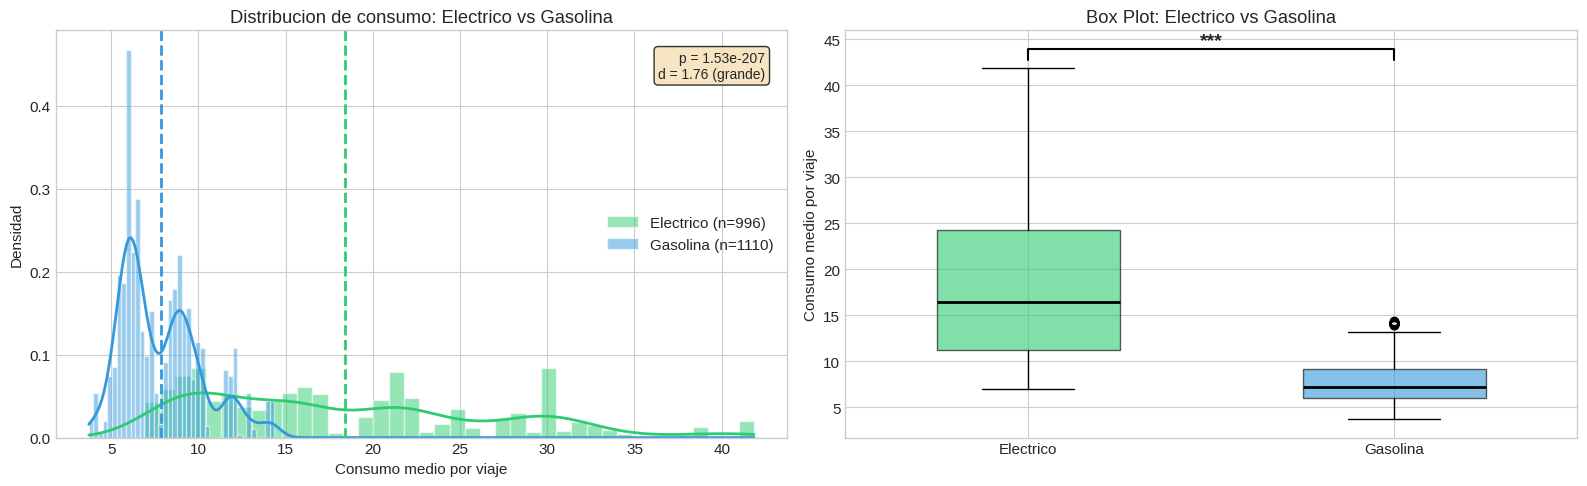

→ Los histogramas muestran cuanto se solapan (o no) las distribuciones
→ Los box plots facilitan comparar medianas y dispersion


In [4]:
# Visualizacion: histogramas/KDE + box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Histogramas con KDE superpuestas
ax = axes[0]
ax.hist(elec_consumption, bins=40, alpha=0.5, color=vtype_colors['electrico'],
        label=f'Electrico (n={len(elec_consumption)})', density=True, edgecolor='white')
ax.hist(gas_consumption, bins=40, alpha=0.5, color=vtype_colors['gasolina'],
        label=f'Gasolina (n={len(gas_consumption)})', density=True, edgecolor='white')

# KDE
from scipy.stats import gaussian_kde
x_range = np.linspace(
    min(elec_consumption.min(), gas_consumption.min()),
    max(elec_consumption.max(), gas_consumption.max()),
    300
)
kde_elec = gaussian_kde(elec_consumption)
kde_gas = gaussian_kde(gas_consumption)
ax.plot(x_range, kde_elec(x_range), color=vtype_colors['electrico'], linewidth=2)
ax.plot(x_range, kde_gas(x_range), color=vtype_colors['gasolina'], linewidth=2)

# Lineas de media
ax.axvline(elec_consumption.mean(), color=vtype_colors['electrico'], linestyle='--', linewidth=2)
ax.axvline(gas_consumption.mean(), color=vtype_colors['gasolina'], linestyle='--', linewidth=2)

ax.set_xlabel('Consumo medio por viaje')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion de consumo: Electrico vs Gasolina')
ax.legend()

# Anotacion del p-value
sig_text = f'p = {p_value:.2e}\nd = {d:.2f} ({interpret_d(d)})'
ax.text(0.97, 0.95, sig_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel 2: Box plots
ax = axes[1]
data_to_plot = [elec_consumption, gas_consumption]
bp = ax.boxplot(data_to_plot, labels=['Electrico', 'Gasolina'], patch_artist=True,
                widths=0.5, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(vtype_colors['electrico'])
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(vtype_colors['gasolina'])
bp['boxes'][1].set_alpha(0.6)

ax.set_ylabel('Consumo medio por viaje')
ax.set_title('Box Plot: Electrico vs Gasolina')

# Anotacion de significancia
y_max = max(elec_consumption.max(), gas_consumption.max())
stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
ax.plot([1, 1, 2, 2], [y_max * 1.02, y_max * 1.05, y_max * 1.05, y_max * 1.02], 'k-', linewidth=1.5)
ax.text(1.5, y_max * 1.06, stars, ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("→ Los histogramas muestran cuanto se solapan (o no) las distribuciones")
print("→ Los box plots facilitan comparar medianas y dispersion")

## 3. ANOVA: Consumo por los 4 tipos de vehiculo

**H0:** Las medias de consumo son iguales en los 4 tipos de vehiculo  
**H1:** Al menos un tipo tiene una media diferente

ANOVA compara **todas las medias simultaneamente**. Si rechazamos H0, sabemos que hay
al menos una diferencia, pero no sabemos **cual**. Para eso necesitamos un test post-hoc.

### Tamaño de efecto: eta-cuadrado (η²)
η² = SS_between / SS_total

| η² | Interpretacion |
|---|---|
| 0.01 | Efecto pequeño |
| 0.06 | Efecto mediano |
| 0.14 | Efecto grande |

In [5]:
# Preparar grupos
groups = {}
for vtype in ['electrico', 'gasolina', 'hibrido', 'deportivo']:
    groups[vtype] = trip_stats[trip_stats['vehicle_type'] == vtype]['consumption_mean'].dropna()

# ANOVA de una via
f_stat, p_anova = stats.f_oneway(*groups.values())

# Calcular eta-cuadrado manualmente
all_data = trip_stats['consumption_mean'].dropna()
grand_mean = all_data.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups.values())
ss_total = sum((all_data - grand_mean) ** 2)
eta_squared = ss_between / ss_total

def interpret_eta(eta):
    if eta < 0.01:
        return "insignificante"
    elif eta < 0.06:
        return "pequeño"
    elif eta < 0.14:
        return "mediano"
    else:
        return "grande"

print("=" * 60)
print("ANOVA: Consumo por tipo de vehiculo (4 grupos)")
print("=" * 60)
for vtype, data in groups.items():
    print(f"  {vtype:12s} - n={len(data):,}, media={data.mean():.4f}, std={data.std():.4f}")
print(f"\nEstadistico F: {f_stat:.4f}")
print(f"p-value:       {p_anova:.2e}")
print(f"η² (eta-cuadrado): {eta_squared:.4f} ({interpret_eta(eta_squared)})")
print(f"\nDecision (α=0.05): {'Rechazamos H0' if p_anova < 0.05 else 'No rechazamos H0'}")
print(f"→ El tipo de vehiculo explica el {eta_squared*100:.1f}% de la varianza en consumo.")

ANOVA: Consumo por tipo de vehiculo (4 grupos)
  electrico    - n=996, media=18.3920, std=8.3884
  gasolina     - n=1,110, media=7.8298, std=2.2827
  hibrido      - n=678, media=5.8941, std=2.6942
  deportivo    - n=450, media=12.0139, std=3.5148

Estadistico F: 1042.3057
p-value:       0.00e+00
η² (eta-cuadrado): 0.4919 (grande)

Decision (α=0.05): Rechazamos H0
→ El tipo de vehiculo explica el 49.2% de la varianza en consumo.


In [6]:
# Post-hoc: Tukey HSD
tukey_data = trip_stats[['consumption_mean', 'vehicle_type']].dropna()
tukey = pairwise_tukeyhsd(
    endog=tukey_data['consumption_mean'],
    groups=tukey_data['vehicle_type'],
    alpha=0.05
)
print("\nPost-hoc Tukey HSD:")
print("=" * 60)
print(tukey)
print("\n→ 'reject=True' indica que esa pareja tiene diferencia significativa")


Post-hoc Tukey HSD:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj  lower    upper   reject
-----------------------------------------------------------
deportivo electrico   6.3781   0.0   5.6236   7.1325   True
deportivo  gasolina  -4.1841   0.0  -4.9264  -3.4418   True
deportivo   hibrido  -6.1198   0.0  -6.9275  -5.3122   True
electrico  gasolina -10.5622   0.0 -11.1419  -9.9824   True
electrico   hibrido -12.4979   0.0 -13.1592 -11.8366   True
 gasolina   hibrido  -1.9358   0.0  -2.5832  -1.2883   True
-----------------------------------------------------------

→ 'reject=True' indica que esa pareja tiene diferencia significativa


/tmp/ipykernel_16576/1102827632.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[v.capitalize() for v in order], patch_artist=True,


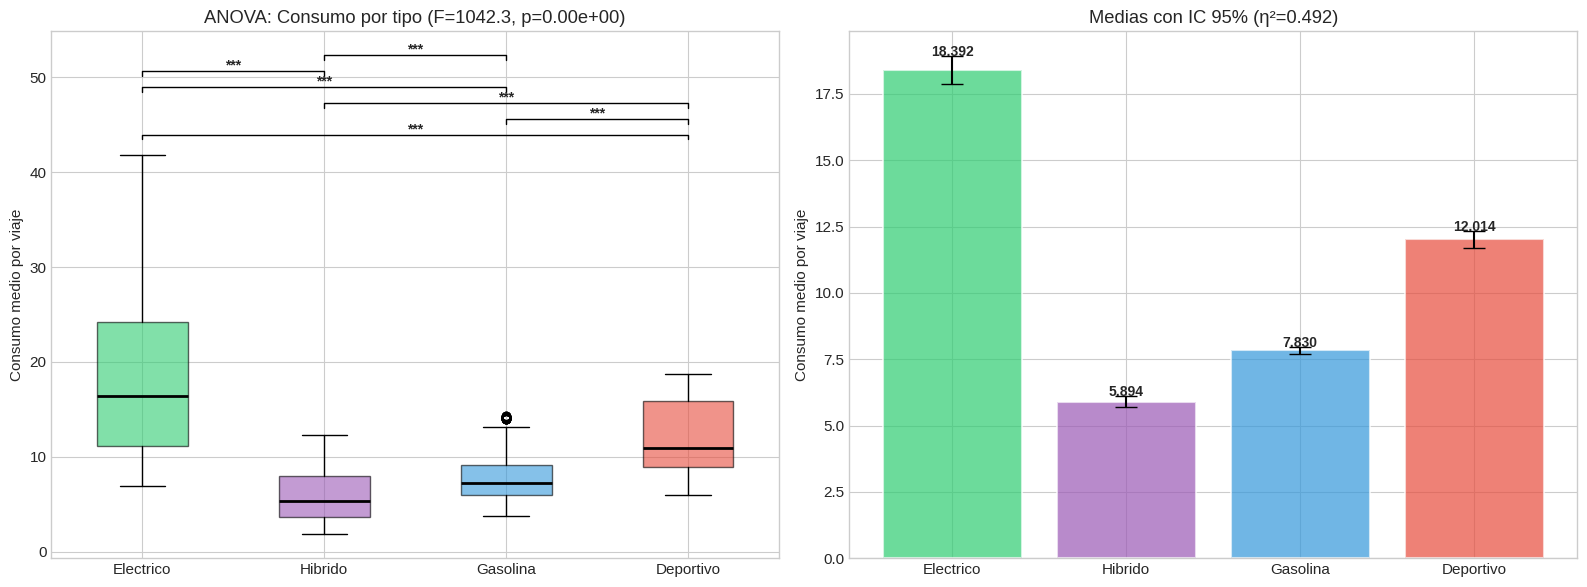

→ Las barras de error (IC 95%) que NO se solapan confirman la significancia
→ El test post-hoc Tukey identifica CUALES pares son diferentes


In [7]:
# Visualizacion ANOVA: box plots con anotaciones de significancia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Box plots por tipo
ax = axes[0]
order = ['electrico', 'hibrido', 'gasolina', 'deportivo']
box_data = [groups[vtype] for vtype in order]
bp = ax.boxplot(box_data, labels=[v.capitalize() for v in order], patch_artist=True,
                widths=0.5, medianprops=dict(color='black', linewidth=2))
for i, vtype in enumerate(order):
    bp['boxes'][i].set_facecolor(vtype_colors[vtype])
    bp['boxes'][i].set_alpha(0.6)

ax.set_ylabel('Consumo medio por viaje')
ax.set_title(f'ANOVA: Consumo por tipo (F={f_stat:.1f}, p={p_anova:.2e})')

# Anotaciones de significancia del Tukey
y_max = max(g.max() for g in groups.values())
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])
sig_pairs = tukey_df[tukey_df['reject'] == True]
bracket_height = y_max * 0.04
for idx, row in sig_pairs.iterrows():
    g1 = order.index(row['group1']) + 1
    g2 = order.index(row['group2']) + 1
    y_pos = y_max * 1.05 + bracket_height * idx
    ax.plot([g1, g1, g2, g2], [y_pos - bracket_height * 0.3, y_pos, y_pos, y_pos - bracket_height * 0.3],
            'k-', linewidth=1)
    p_val = row['p-adj']
    star = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.text((g1 + g2) / 2, y_pos + bracket_height * 0.1, star,
            ha='center', fontsize=10, fontweight='bold')

# Panel 2: Medias con IC 95%
ax = axes[1]
means = []
cis = []
for vtype in order:
    data = groups[vtype]
    mean = data.mean()
    se = data.std() / np.sqrt(len(data))
    ci = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=se)
    means.append(mean)
    cis.append(mean - ci[0])

bars = ax.bar(range(len(order)), means, yerr=cis, capsize=8,
              color=[vtype_colors[v] for v in order], alpha=0.7,
              edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([v.capitalize() for v in order])
ax.set_ylabel('Consumo medio por viaje')
ax.set_title(f'Medias con IC 95% (η²={eta_squared:.3f})')

# Valores sobre las barras
for i, (m, ci) in enumerate(zip(means, cis)):
    ax.text(i, m + ci + 0.01, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("→ Las barras de error (IC 95%) que NO se solapan confirman la significancia")
print("→ El test post-hoc Tukey identifica CUALES pares son diferentes")

## 4. t-test: Conduccion nocturna vs diurna

**H0:** La velocidad media es igual en viajes diurnos y nocturnos  
**H1:** La velocidad media difiere entre dia y noche

Definimos:
- **Nocturno**: hora promedio del viaje entre 22:00-6:00
- **Diurno**: hora promedio del viaje entre 7:00-21:00

Hipotesis de negocio: los conductores nocturnos van mas rapido por menor trafico.

In [8]:
# Datos por periodo
speed_diurno = trip_stats[trip_stats['periodo'] == 'diurno']['speed_mean'].dropna()
speed_nocturno = trip_stats[trip_stats['periodo'] == 'nocturno']['speed_mean'].dropna()

# t-test
t_stat_dn, p_value_dn = stats.ttest_ind(speed_diurno, speed_nocturno, equal_var=False)
d_dn = cohens_d(speed_diurno, speed_nocturno)

print("=" * 60)
print("T-TEST: Velocidad diurna vs nocturna")
print("=" * 60)
print(f"Diurno   - n={len(speed_diurno):,}, media={speed_diurno.mean():.2f} km/h, std={speed_diurno.std():.2f}")
print(f"Nocturno - n={len(speed_nocturno):,}, media={speed_nocturno.mean():.2f} km/h, std={speed_nocturno.std():.2f}")
print(f"\nEstadistico t: {t_stat_dn:.4f}")
print(f"p-value:       {p_value_dn:.2e}")
print(f"Cohen's d:     {d_dn:.4f} ({interpret_d(d_dn)})")
print(f"Diferencia:    {speed_diurno.mean() - speed_nocturno.mean():.2f} km/h")
print(f"\nDecision (α=0.05): {'Rechazamos H0' if p_value_dn < 0.05 else 'No rechazamos H0'}")

if p_value_dn < 0.05:
    faster = 'diurno' if speed_diurno.mean() > speed_nocturno.mean() else 'nocturno'
    print(f"→ Los viajes {faster}s tienen velocidad significativamente mayor.")
else:
    print("→ No hay evidencia suficiente de diferencia en velocidad dia/noche.")
print(f"→ Tamaño de efecto {interpret_d(d_dn)}: la diferencia {'es' if abs(d_dn) >= 0.5 else 'puede no ser'} relevante en la practica.")

T-TEST: Velocidad diurna vs nocturna
Diurno   - n=3,115, media=50.79 km/h, std=24.27
Nocturno - n=119, media=49.59 km/h, std=23.03

Estadistico t: 0.5562
p-value:       5.79e-01
Cohen's d:     0.0495 (insignificante)
Diferencia:    1.20 km/h

Decision (α=0.05): No rechazamos H0
→ No hay evidencia suficiente de diferencia en velocidad dia/noche.
→ Tamaño de efecto insignificante: la diferencia puede no ser relevante en la practica.


/tmp/ipykernel_16576/3057770697.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([speed_diurno, speed_nocturno], labels=['Diurno', 'Nocturno'],


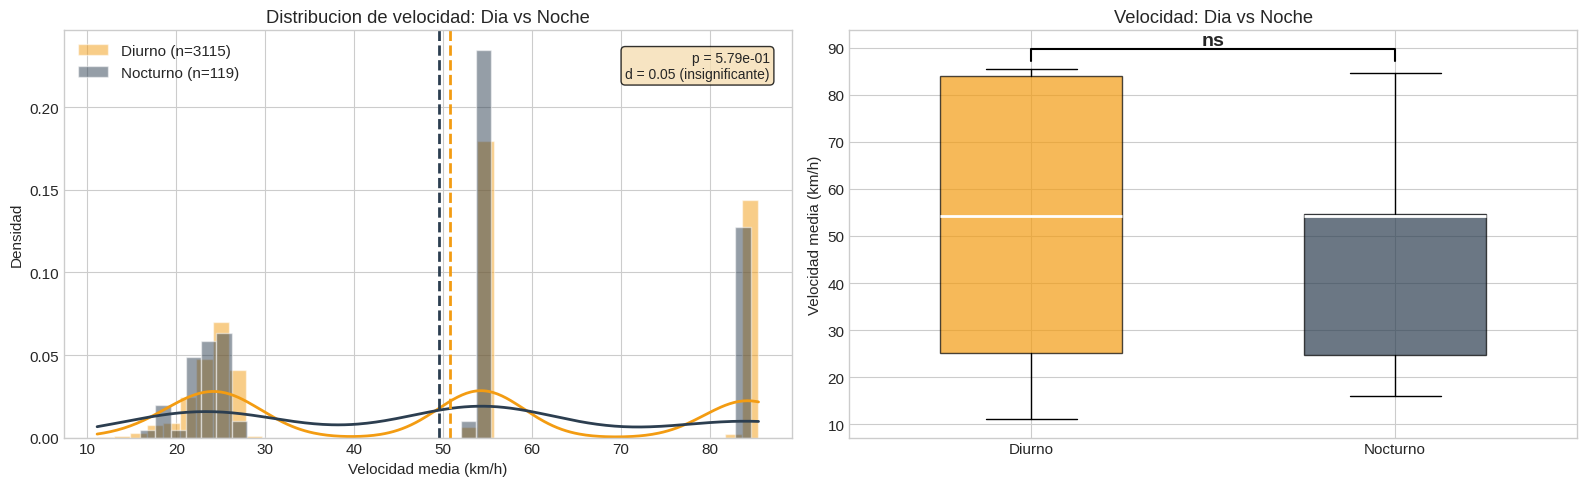

→ Las distribuciones permiten ver visualmente el grado de solapamiento
→ Mayor solapamiento = menor tamaño de efecto practico


In [9]:
# Visualizacion dia/noche
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_dn = {'diurno': '#f39c12', 'nocturno': '#2c3e50'}

# Panel 1: Histogramas con KDE
ax = axes[0]
ax.hist(speed_diurno, bins=40, alpha=0.5, color=colors_dn['diurno'],
        label=f'Diurno (n={len(speed_diurno)})', density=True, edgecolor='white')
ax.hist(speed_nocturno, bins=40, alpha=0.5, color=colors_dn['nocturno'],
        label=f'Nocturno (n={len(speed_nocturno)})', density=True, edgecolor='white')

x_range = np.linspace(
    min(speed_diurno.min(), speed_nocturno.min()),
    max(speed_diurno.max(), speed_nocturno.max()),
    300
)
kde_d = gaussian_kde(speed_diurno)
kde_n = gaussian_kde(speed_nocturno)
ax.plot(x_range, kde_d(x_range), color=colors_dn['diurno'], linewidth=2)
ax.plot(x_range, kde_n(x_range), color=colors_dn['nocturno'], linewidth=2)

ax.axvline(speed_diurno.mean(), color=colors_dn['diurno'], linestyle='--', linewidth=2)
ax.axvline(speed_nocturno.mean(), color=colors_dn['nocturno'], linestyle='--', linewidth=2)
ax.set_xlabel('Velocidad media (km/h)')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion de velocidad: Dia vs Noche')
ax.legend()

sig_text = f'p = {p_value_dn:.2e}\nd = {d_dn:.2f} ({interpret_d(d_dn)})'
ax.text(0.97, 0.95, sig_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel 2: Box plots
ax = axes[1]
bp = ax.boxplot([speed_diurno, speed_nocturno], labels=['Diurno', 'Nocturno'],
                patch_artist=True, widths=0.5, medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(colors_dn['diurno'])
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(colors_dn['nocturno'])
bp['boxes'][1].set_alpha(0.7)

ax.set_ylabel('Velocidad media (km/h)')
ax.set_title('Velocidad: Dia vs Noche')

y_max = max(speed_diurno.max(), speed_nocturno.max())
stars = '***' if p_value_dn < 0.001 else '**' if p_value_dn < 0.01 else '*' if p_value_dn < 0.05 else 'ns'
ax.plot([1, 1, 2, 2], [y_max * 1.02, y_max * 1.05, y_max * 1.05, y_max * 1.02], 'k-', linewidth=1.5)
ax.text(1.5, y_max * 1.06, stars, ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("→ Las distribuciones permiten ver visualmente el grado de solapamiento")
print("→ Mayor solapamiento = menor tamaño de efecto practico")

## 5. Mann-Whitney U: Alternativa no parametrica

### ¿Cuando usar parametrico vs no parametrico?

| Criterio | Parametrico (t-test) | No parametrico (Mann-Whitney U) |
|---|---|---|
| Supuesto | Normalidad (o n grande por TCL) | Ninguno sobre la forma |
| Compara | Medias | Rangos (distribucion general) |
| Potencia | Mayor si se cumplen supuestos | Menor, pero mas robusto |
| Cuando usar | n > 30 y sin outliers extremos | n pequeño, datos sesgados, ordinales |

Repetimos la comparacion electrico vs gasolina en consumo, pero con **Mann-Whitney U**.

**H0:** Las distribuciones de consumo son iguales  
**H1:** Las distribuciones difieren

### Tamaño de efecto: Correlacion rango-biserial
r = 1 - (2U)/(n1 * n2)

| r | Interpretacion |
|---|---|
| 0.1 | Pequeño |
| 0.3 | Mediano |
| 0.5 | Grande |

In [10]:
# Mann-Whitney U test
u_stat, p_mann = stats.mannwhitneyu(elec_consumption, gas_consumption, alternative='two-sided')

# Correlacion rango-biserial como tamaño de efecto
n1, n2 = len(elec_consumption), len(gas_consumption)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

def interpret_r(r):
    r_abs = abs(r)
    if r_abs < 0.1:
        return "insignificante"
    elif r_abs < 0.3:
        return "pequeño"
    elif r_abs < 0.5:
        return "mediano"
    else:
        return "grande"

print("=" * 60)
print("MANN-WHITNEY U: Electricos vs Gasolina (consumo) - No parametrico")
print("=" * 60)
print(f"Electricos  - n={n1:,}, mediana={elec_consumption.median():.4f}")
print(f"Gasolina    - n={n2:,}, mediana={gas_consumption.median():.4f}")
print(f"\nEstadistico U: {u_stat:.1f}")
print(f"p-value:       {p_mann:.2e}")
print(f"r (rango-biserial): {r_rb:.4f} ({interpret_r(r_rb)})")
print(f"\nDecision (α=0.05): {'Rechazamos H0' if p_mann < 0.05 else 'No rechazamos H0'}")

print(f"\n--- Comparacion con t-test ---")
print(f"t-test p-value:      {p_value:.2e}  |  Cohen's d: {d:.4f}")
print(f"Mann-Whitney p-value: {p_mann:.2e}  |  r rango-biserial: {r_rb:.4f}")
concordancia = 'Si' if (p_value < 0.05) == (p_mann < 0.05) else 'No'
print(f"\n→ ¿Concuerdan ambos tests? {concordancia}")
print("→ Cuando ambos concuerdan, tenemos mayor confianza en el resultado.")
print("→ Si discrepan, revisar supuestos (normalidad, outliers, tamaño de muestra).")

MANN-WHITNEY U: Electricos vs Gasolina (consumo) - No parametrico
Electricos  - n=996, mediana=16.3949
Gasolina    - n=1,110, mediana=7.2109

Estadistico U: 1019698.0
p-value:       3.17e-246
r (rango-biserial): -0.8447 (grande)

Decision (α=0.05): Rechazamos H0

--- Comparacion con t-test ---
t-test p-value:      1.53e-207  |  Cohen's d: 1.7598
Mann-Whitney p-value: 3.17e-246  |  r rango-biserial: -0.8447

→ ¿Concuerdan ambos tests? Si
→ Cuando ambos concuerdan, tenemos mayor confianza en el resultado.
→ Si discrepan, revisar supuestos (normalidad, outliers, tamaño de muestra).


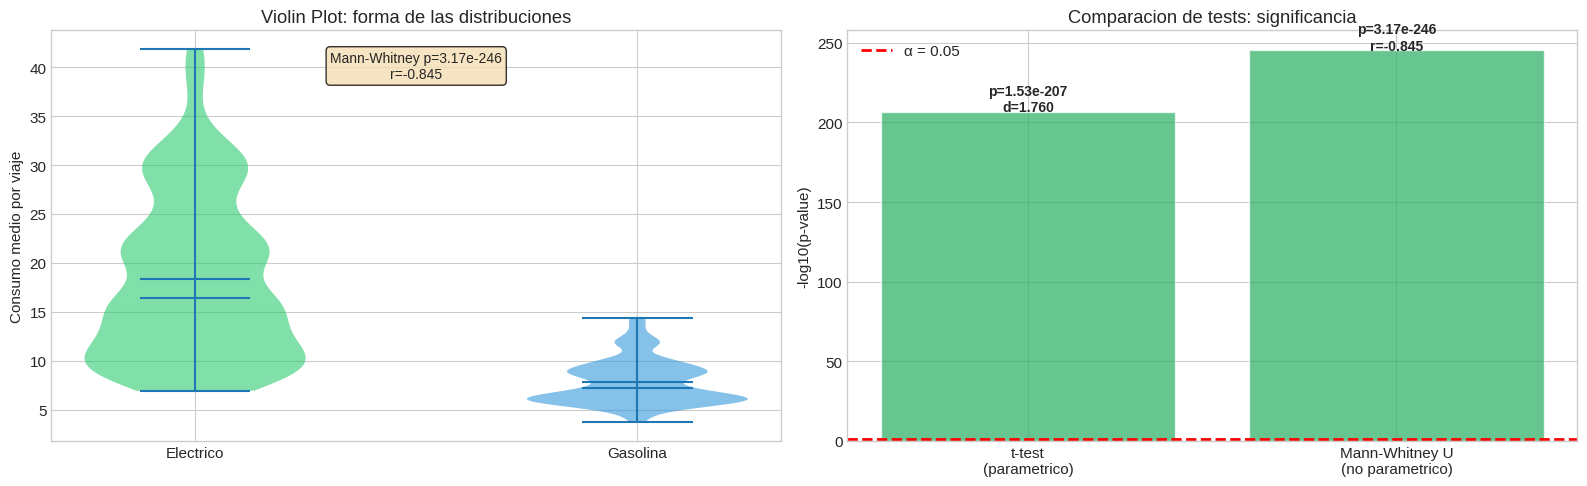

→ El violin plot muestra la forma completa de cada distribucion
→ -log10(p): valores por encima de la linea roja son significativos
→ Verde = significativo, Rojo = no significativo


In [11]:
# Visualizacion: comparacion parametrico vs no parametrico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Violin plot (muestra la forma de la distribucion)
ax = axes[0]
comparison_df = trip_stats[trip_stats['vehicle_type'].isin(['electrico', 'gasolina'])].copy()
parts = ax.violinplot(
    [elec_consumption.values, gas_consumption.values],
    positions=[1, 2], showmeans=True, showmedians=True
)
colors_v = [vtype_colors['electrico'], vtype_colors['gasolina']]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_v[i])
    pc.set_alpha(0.6)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Electrico', 'Gasolina'])
ax.set_ylabel('Consumo medio por viaje')
ax.set_title('Violin Plot: forma de las distribuciones')
ax.text(0.5, 0.95, f'Mann-Whitney p={p_mann:.2e}\nr={r_rb:.3f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel 2: Resumen visual de ambos tests
ax = axes[1]
tests = ['t-test\n(parametrico)', 'Mann-Whitney U\n(no parametrico)']
p_values = [p_value, p_mann]
effects = [abs(d), abs(r_rb)]
effect_labels = [f'd={d:.3f}', f'r={r_rb:.3f}']

bar_colors = ['#27ae60' if p < 0.05 else '#e74c3c' for p in p_values]
bars = ax.bar(tests, [-np.log10(p) for p in p_values], color=bar_colors, alpha=0.7, edgecolor='white')
ax.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Comparacion de tests: significancia')
ax.legend()

for bar, p, eff_label in zip(bars, p_values, effect_labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'p={p:.2e}\n{eff_label}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("→ El violin plot muestra la forma completa de cada distribucion")
print("→ -log10(p): valores por encima de la linea roja son significativos")
print("→ Verde = significativo, Rojo = no significativo")

## Resumen

### Hallazgos clave

| Test | Comparacion | p-value | Efecto | Conclusion |
|---|---|---|---|---|
| t-test | Electrico vs Gasolina (consumo) | Ver arriba | Cohen's d | Comparacion directa |
| ANOVA | 4 tipos de vehiculo (consumo) | Ver arriba | η² | Comparacion global |
| Tukey HSD | Pares especificos | Ver arriba | - | Detalle por pares |
| t-test | Dia vs Noche (velocidad) | Ver arriba | Cohen's d | Efecto del horario |
| Mann-Whitney U | Electrico vs Gasolina (consumo) | Ver arriba | r rango-biserial | Validacion robusta |

### Implicaciones de negocio
- → Las diferencias de consumo entre tipos de vehiculo NO son solo ruido: son reales y medibles
- → El tamaño de efecto indica si la diferencia es **practicamente relevante** (no solo estadisticamente)
- → Los tests no parametricos confirman (o no) los resultados parametricos, dando mayor robustez
- → El analisis dia/noche permite ajustar estrategias de gestion de flota por horario

### Aprendizajes metodologicos
- → Un p-value pequeño no implica un efecto grande: siempre reportar tamaño de efecto
- → ANOVA dice "hay diferencia" pero NO "cual": necesitamos post-hoc (Tukey)
- → Usar tests no parametricos como validacion cuando hay dudas sobre normalidad

### Siguiente
→ `04_hypothesis_testing_surveys.ipynb`: Pruebas de hipotesis en datos de encuestas (chi-cuadrado, correlaciones)